# Preprocessing

In [39]:
# imports
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import mne

from pyprep.prep_pipeline import PrepPipeline
from autoreject import AutoReject
from src.eeg_utils import crop_rest_conditions, load_rest_eeg, plot_psd_comparison


## Step 1 line-noise inspection and removal

- Before final band-pass filtering, PSD was inspected up to `100 Hz` to assess whether a `50 Hz` line-noise peak was present.
- Line-noise removal was then applied using MNE's notch filtering with `method="spectrum_fit"`, which is similar to the PREP-style selective removal of narrowband electrical contamination.
- PSD was then checked again after denoising before taking the signal forward into the rest of preprocessing.


In [ ]:
# Load subject 1 resting EEG and split into eyes-open / eyes-closed segments
raw = load_rest_eeg("../data/ds004796/sub-01/eeg/sub-01_task-rest_eeg.vhdr", preload=True)
raw_eyes_open, raw_eyes_closed, markers = crop_rest_conditions(raw)

print(markers)
print(f"Eyes-open duration: {raw_eyes_open.times[-1]:.2f} s")
print(f"Eyes-closed duration: {raw_eyes_closed.times[-1]:.2f} s")


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


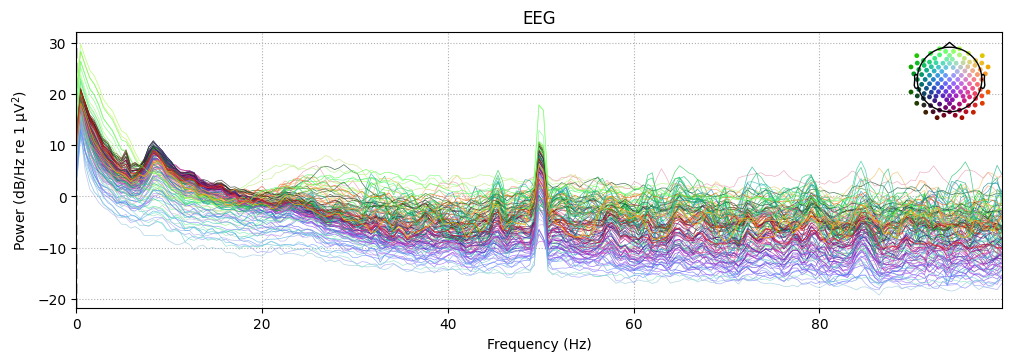

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


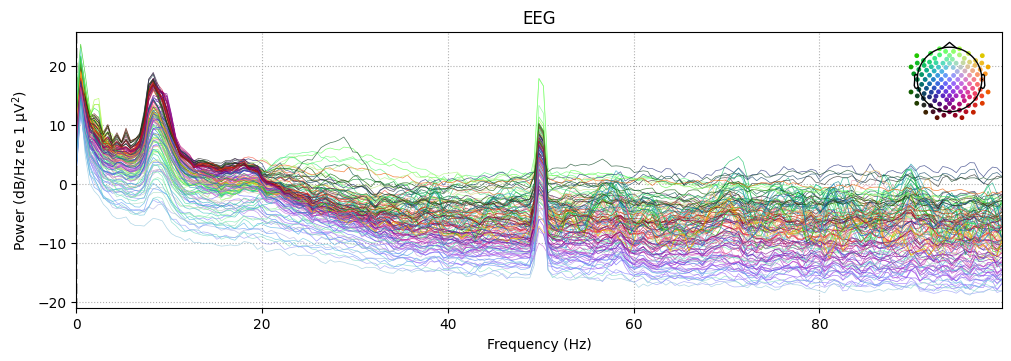

In [5]:
# Check PSD before line-noise removal, extending to 100 Hz to inspect 50 Hz contamination
fig_open_before = raw_eyes_open.plot_psd(fmax=100)
plt.show()

fig_closed_before = raw_eyes_closed.plot_psd(fmax=100)
plt.show()


In [6]:
# Apply line-noise removal at 50 Hz before band-pass filtering
raw_eyes_open_denoised = raw_eyes_open.copy().notch_filter(
    freqs=[50],
    method="spectrum_fit",
    filter_length="10s"
)

raw_eyes_closed_denoised = raw_eyes_closed.copy().notch_filter(
    freqs=[50],
    method="spectrum_fit",
    filter_length="10s"
)


Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 : 5969 windows
Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 : 9017 windows


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


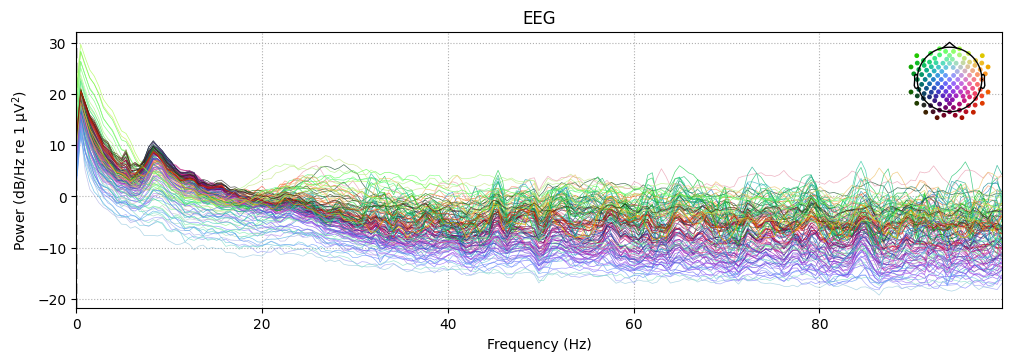

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


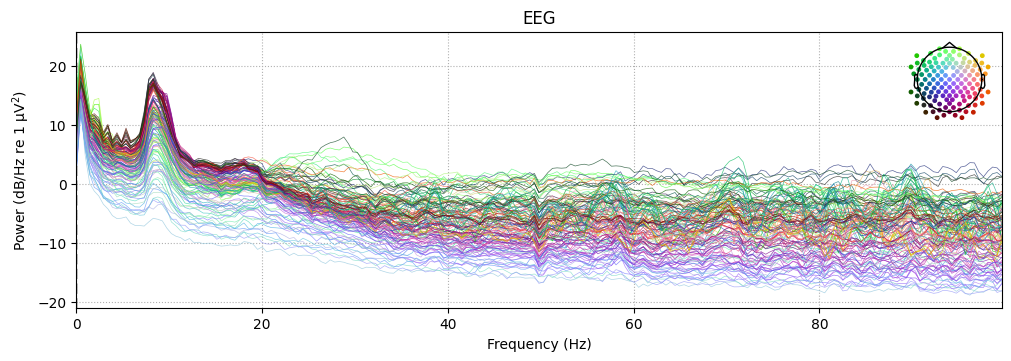

In [7]:
# Check PSD again after line-noise removal
fig_open_after = raw_eyes_open_denoised.plot_psd(fmax=100)
plt.show()

fig_closed_after = raw_eyes_closed_denoised.plot_psd(fmax=100)
plt.show()


  ## Step 2: Band-pass filtering

  - A 1 to 40 Hz band-pass filter was then applied separately to each segment.
  - This filtering step was used to reduce very slow drift below 1 Hz and attenuate higher-frequency noise above 40 Hz, while preserving the main EEG frequency range of interest for resting-state analysis.
  - Filtering was implemented in MNE using a zero-phase FIR filter, which is appropriate for offline preprocessing because it minimises phase distortion in the signal.

In [ ]:
# Apply the 1 to 40 Hz band-pass filter to the denoised data
raw_eyes_open_filt = raw_eyes_open_denoised.copy().filter(l_freq=1, h_freq=40)
raw_eyes_closed_filt = raw_eyes_closed_denoised.copy().filter(l_freq=1, h_freq=40)

print(raw_eyes_open_filt)
print(raw_eyes_closed_filt)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 

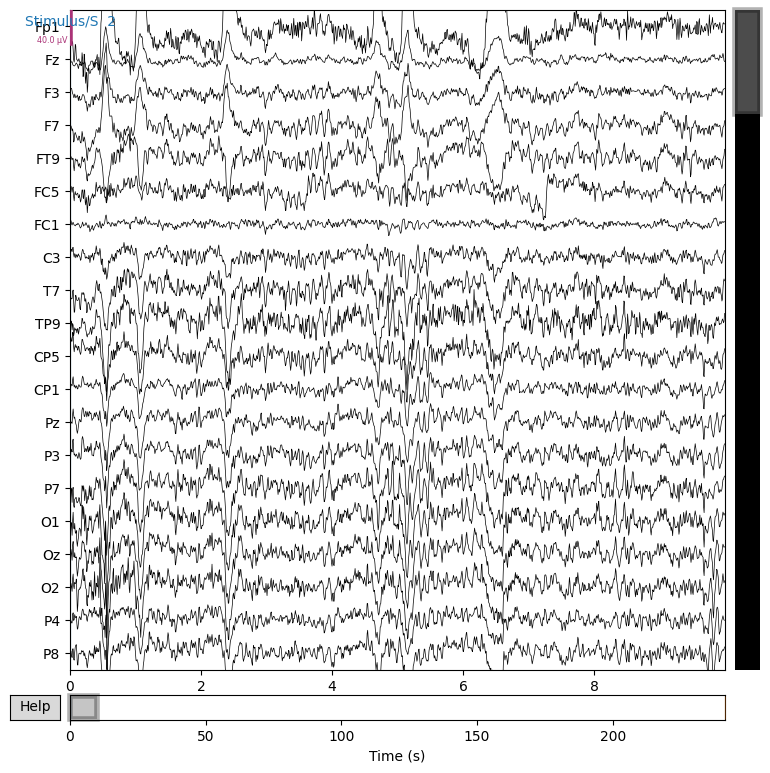

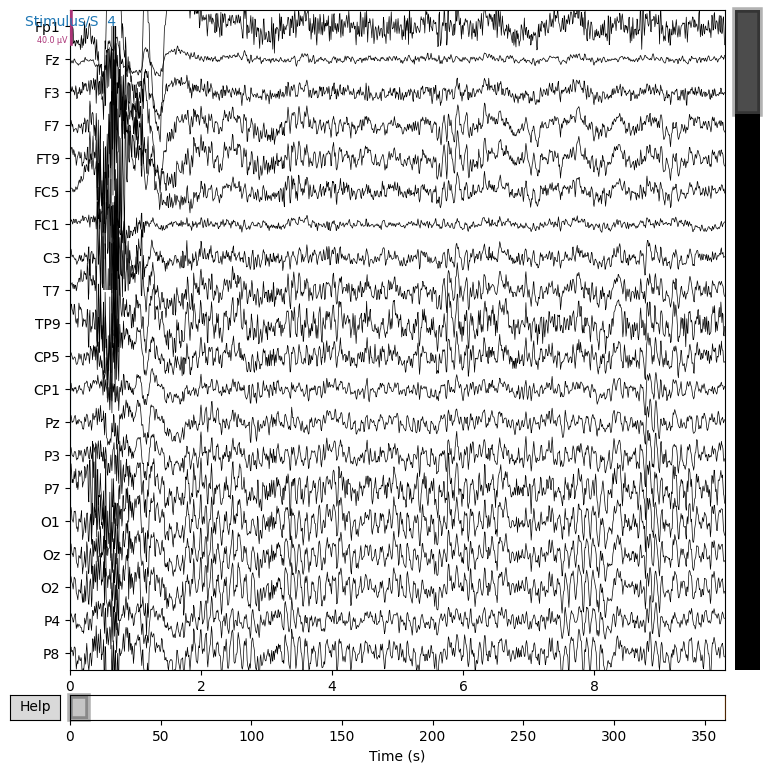

In [9]:
# Quick visual check of the filtered segments
fig_open = raw_eyes_open_filt.plot(n_channels=20, duration=10)
plt.show()

fig_closed = raw_eyes_closed_filt.plot(n_channels=20, duration=10)
plt.show()


## Step 3: PREP-style bad-channel detection and rereferencing

- PyPREP was used here as a PREP-style approach to automate robust bad-channel detection, interpolation, and rereferencing.
- In the full PREP pipeline, line-noise removal and 1 Hz detrending can also be handled internally. In this notebook, line-noise removal was carried out explicitly in the previous step, so the PREP stage below is being used mainly for robust referencing and channel cleaning.
- The pipeline iteratively identifies noisy EEG channels, computes a cleaner reference excluding those channels, interpolates channels judged to be bad, and then recomputes the reference.
- Running this separately on the eyes-open and eyes-closed segments provides a reproducible way to standardise the recordings before later epoching, artifact rejection, or ICA.


In [10]:
# Set PREP parameters.
# line_freqs is left empty here because line-noise removal was already applied above.
montage = raw.get_montage()

prep_params = {
    "ref_chs": "eeg",
    "reref_chs": "eeg",
    "line_freqs": [],
    "max_iterations": 4,
}


In [13]:
# Run PREP-style robust channel cleaning and rereferencing on the eyes-open segment
prep_open = PrepPipeline(
    raw_eyes_open_denoised.copy(),
    prep_params=prep_params,
    montage=montage,
    ransac=True,
    random_state=42,
)
prep_open.fit()
raw_eyes_open_prep = prep_open.raw_eeg

print("Eyes open interpolated channels:", prep_open.interpolated_channels)
print("Eyes open channels still noisy after interpolation:", prep_open.still_noisy_channels)


Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/48 [00:00<?,       ?it/s]


RANSAC done!


2026-05-02 15:36:16,322 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': ['Cz', 'FC2', 'FFC1h', 'FFC2h', 'FCC1h', 'FCC2h'], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': ['AF4', 'AFF6h'], 'bad_by_ransac': [], 'bad_by_manual': [], 'bad_all': ['AFF6h', 'FFC1h', 'FFC2h', 'FC2', 'AF4', 'Cz', 'FCC2h', 'FCC1h']}


Executing RANSAC
This may take a while, so be patient...


...

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 114 sensor positions
Interpolating 13 sensors
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/48 [00:00<?,       ?it/s]


RANSAC done!
Found 12 uniquely bad channels:

0 by NaN: []

0 by flat: []

1 by deviation: ['Fp1']

0 by HF noise: []

3 by correlation: ['TP10', 'F4', 'AFF6h']

0 by SNR: []

0 by dropout: []

10 by PSD: ['Fp1', 'Fp2', 'AF7', 'AF3', 'AF8', 'AF4', 'AFp1', 'FCC6h', 'AFF6h', 'AFp2']

1 by RANSAC: [np.str_('FCC6h')]

0 by manual: []

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 115 sensor positions
Interpolating 12 sensors
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Executing RANSAC
This may take a while, so

  0%|          |  : 0/48 [00:00<?,       ?it/s]


RANSAC done!
Eyes open interpolated channels: ['AFF6h', 'FCC6h', 'AF3', 'AFp2', 'AF8', 'TP10', 'F4', 'AF4', 'AFp1', 'Fp2', 'AF7', 'Fp1']
Eyes open channels still noisy after interpolation: [np.str_('FTT8h')]


In [17]:
# Run PREP-style robust channel cleaning and rereferencing on the eyes-closed segment
prep_closed = PrepPipeline(
    raw_eyes_closed_denoised.copy(),
    prep_params=prep_params,
    montage=montage,
    ransac=True,
    random_state=42,
)
prep_closed.fit()
raw_eyes_closed_prep = prep_closed.raw_eeg

print("Eyes closed interpolated channels:", prep_closed.interpolated_channels)
print("Eyes closed channels still noisy after interpolation:", prep_closed.still_noisy_channels)


Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/72 [00:00<?,       ?it/s]


RANSAC done!


2026-05-02 15:50:11,474 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': ['AFp1', 'AFp2'], 'bad_by_correlation': ['Cz', 'FFC2h', 'FCC2h'], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': [], 'bad_by_ransac': [], 'bad_by_manual': [], 'bad_all': ['AFp2', 'FFC2h', 'Cz', 'AFp1', 'FCC2h']}


Executing RANSAC
This may take a while, so be patient...


...

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 117 sensor positions
Interpolating 10 sensors
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/72 [00:00<?,       ?it/s]


RANSAC done!
Found 10 uniquely bad channels:

0 by NaN: []

0 by flat: []

0 by deviation: []

0 by HF noise: []

1 by correlation: ['TP10']

0 by SNR: []

0 by dropout: []

10 by PSD: ['Fp1', 'TP9', 'TP10', 'AF3', 'P5', 'AF4', 'AFp1', 'AFF5h', 'TPP9h', 'AFF6h']

0 by RANSAC: []

0 by manual: []

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 117 sensor positions
Interpolating 10 sensors
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/72 [00:00<?,       ?it/s]


RANSAC done!
Eyes closed interpolated channels: ['AFF5h', 'AFF6h', 'AF3', 'TP10', 'TP9', 'AF4', 'AFp1', 'TPP9h', 'P5', 'Fp1']
Eyes closed channels still noisy after interpolation: ['AFp2', 'F4', 'PPO9h', 'P9', 'TPP7h', 'F6']


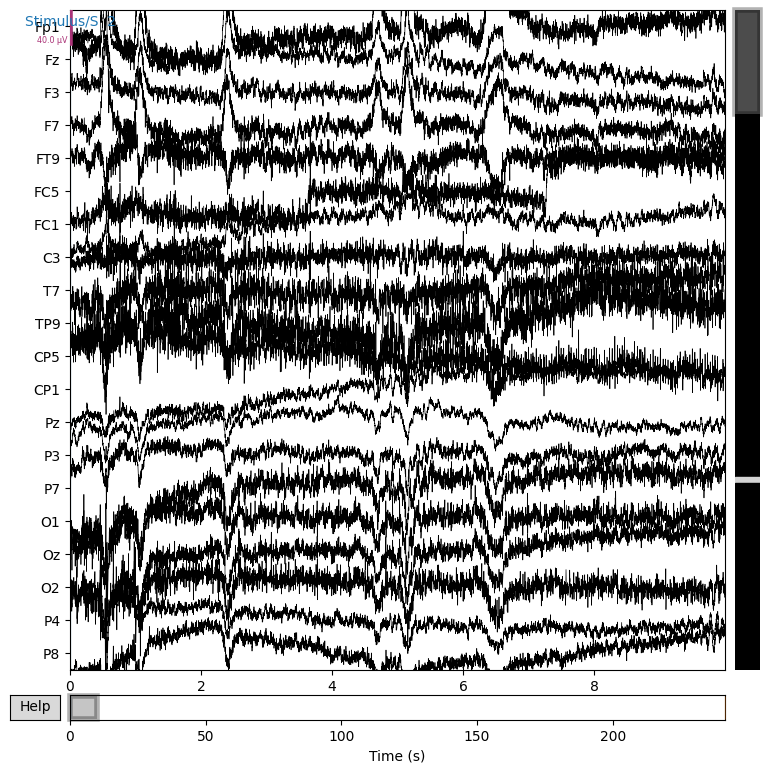

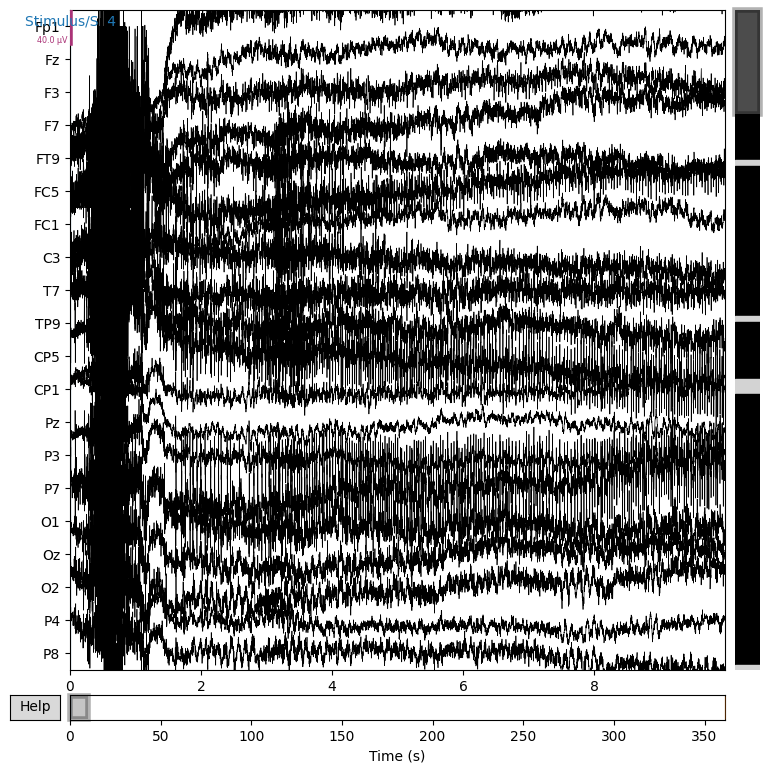

In [25]:
# Quick visual check after PREP-style cleaning
raw_eyes_open_prep.plot(n_channels=20, duration=10)
plt.show()

raw_eyes_closed_prep.plot(n_channels=20, duration=10)
plt.show()


## Step 4: PSD comparison across preprocessing stages

- Compare the eyes-open and eyes-closed PSD before preprocessing and after the full preprocessing chain.
- This provides a quick check that preprocessing reduces noise while preserving the expected alpha-band enhancement in the eyes-closed condition.


Effective window size : 2.048 (s)
Effective window size : 2.048 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidt

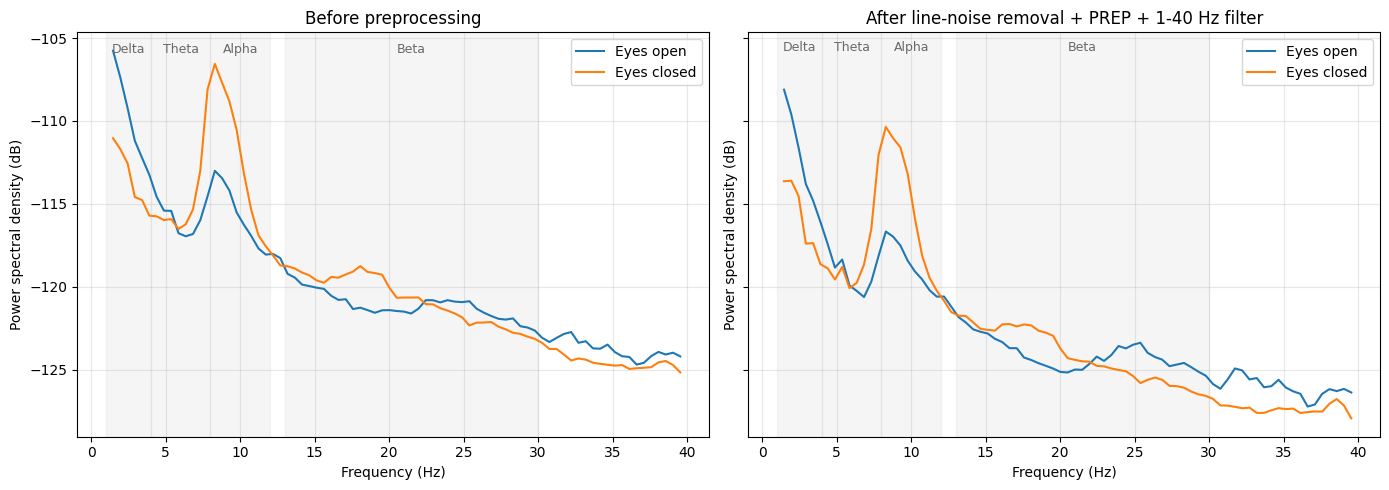

In [34]:
# Compare PSD before preprocessing vs after line-noise removal + PREP + band-pass filtering
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Before preprocessing
plot_psd_comparison(
    raw_eyes_open,
    raw_eyes_closed,
    fmin=1,
    fmax=40,
    title="Before preprocessing",
    ax=axes[0],
)

# After line-noise removal + PREP + band-pass filtering
raw_eyes_open_final = raw_eyes_open_prep.copy().filter(l_freq=1, h_freq=40)
raw_eyes_closed_final = raw_eyes_closed_prep.copy().filter(l_freq=1, h_freq=40)

plot_psd_comparison(
    raw_eyes_open_final,
    raw_eyes_closed_final,
    fmin=1,
    fmax=40,
    title="After line-noise removal + PREP + 1-40 Hz filter",
    ax=axes[1],
)

plt.tight_layout()
plt.savefig("../figures/exploratory/sub-01_rest_psd_preprocessing_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 5: fixed-length epoching and simple bad-epoch rejection

- The preprocessed eyes-open and eyes-closed signals are split into fixed-length epochs for resting-state analysis.
- A simple peak-to-peak EEG rejection threshold is used as a first-pass artifact filter before moving to more complex rejection methods.
- This allows a quick check of how much usable data remains in each condition after preprocessing.


In [35]:
# Create fixed-length epochs from the final preprocessed signals
epoch_duration = 2.0  # seconds
reject_criteria = dict(eeg=150e-6)  # 150 uV peak-to-peak threshold

epochs_open = mne.make_fixed_length_epochs(
    raw_eyes_open_final, duration=epoch_duration, preload=True
)
epochs_closed = mne.make_fixed_length_epochs(
    raw_eyes_closed_final, duration=epoch_duration, preload=True
)

print(f"Eyes-open epochs before rejection: {len(epochs_open)}")
print(f"Eyes-closed epochs before rejection: {len(epochs_closed)}")


Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 2000 original time points ...
0 bad epochs dropped
Not setting metadata
180 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 180 events and 2000 original time points ...
0 bad epochs dropped
Eyes-open epochs before rejection: 120
Eyes-closed epochs before rejection: 180


In [36]:
# Apply simple amplitude-based bad-epoch rejection
epochs_open_clean = epochs_open.copy().drop_bad(reject=reject_criteria)
epochs_closed_clean = epochs_closed.copy().drop_bad(reject=reject_criteria)

print(f"Eyes-open epochs after rejection: {len(epochs_open_clean)}")
print(f"Eyes-closed epochs after rejection: {len(epochs_closed_clean)}")
print(f"Eyes-open epochs dropped: {len(epochs_open) - len(epochs_open_clean)}")
print(f"Eyes-closed epochs dropped: {len(epochs_closed) - len(epochs_closed_clean)}")


    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF7', 'AF3', 'AFp1', 'AFF5h', 'AFp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AFp1', 'AFp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AFp1', 'AFp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF3', 'AFz', 'AFp1', 'AFF5h', 'AFp2']
    Rejecting  epoch based on EEG : ['Fp1', 'AFp1']
    Rejecting  epoch based on EEG : ['Fp1', 'AFp1']
    Rejecting  epoch based on EEG : ['AFp1', 'AFp2']
    Rejecting  epoch based on EEG : ['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'C3', 'T7', 'FT10', 'FC6', 'F8', 'Fp2', 'AF7', 'AF3', 'F5', 'FC3', 'C5', 'FC4', 'F6', 'AF8', 'F9', 'FFC5h', 'FTT7h', 'FFC6h', 'AFp1', 'AFF5h', 'FFT9h', 'FFT7h', 'FCC5h', 'FFT8h', 'FFT10h', 'AFp2']
8 bad epochs dropped
    Rejecting  epoch based on EEG : ['Fp1', 'F7', 'FT9', 'FC5', 'C3', 'T7', 'T8', 'FC6', 'F8', 'Fp2', 'AF7', 'AF3', 'F5', 'FT7', 'FC3', 'C5', 'TP8', 'C6', 'FC4', 'FT8', 'AF8', 'AF4', 'F9', 'FFC5h', 'FTT7h', 'FCC3h', 'CCP5h', 'CCP6h', 'FTT8h'

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


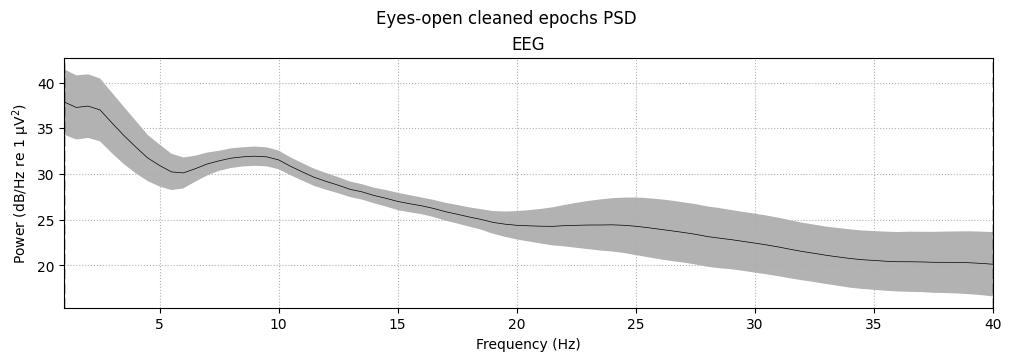

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


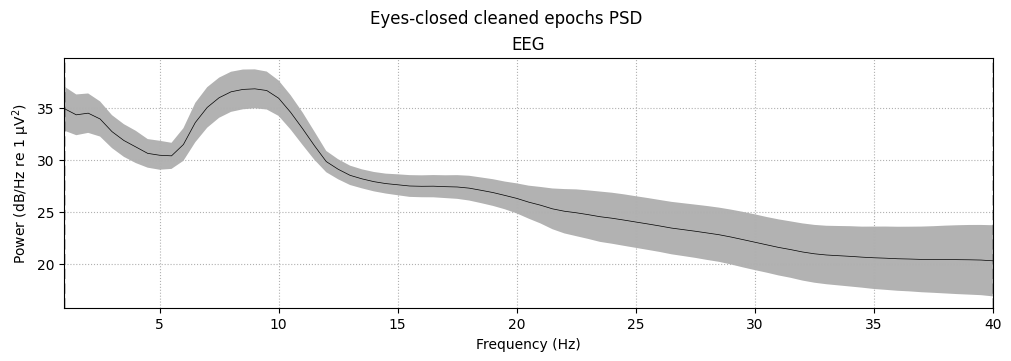

In [37]:
# Quick PSD check on the cleaned epochs
fig_open = epochs_open_clean.compute_psd(fmin=1, fmax=40).plot(average=True, show=False)
fig_open.suptitle("Eyes-open cleaned epochs PSD")
plt.show()

fig_closed = epochs_closed_clean.compute_psd(fmin=1, fmax=40).plot(average=True, show=False)
fig_closed.suptitle("Eyes-closed cleaned epochs PSD")
plt.show()


## Step 6: adaptive bad-epoch rejection with autoreject

- `autoreject` is used as a more flexible alternative to the single global amplitude threshold.
- It learns rejection thresholds from the data and can interpolate a small number of bad sensors within an epoch rather than dropping the whole epoch immediately.
- This is useful for comparing a simple baseline rejection strategy against a more scalable automated approach.


In [40]:
# Fit autoreject separately for eyes-open and eyes-closed epochs
ar_open = AutoReject(random_state=42, verbose=True)
ar_closed = AutoReject(random_state=42, verbose=True)

epochs_open_ar, reject_log_open = ar_open.fit_transform(epochs_open, return_log=True)
epochs_closed_ar, reject_log_closed = ar_closed.fit_transform(epochs_closed, return_log=True)

print(f"Eyes-open epochs after autoreject: {len(epochs_open_ar)}")
print(f"Eyes-closed epochs after autoreject: {len(epochs_closed_ar)}")
print(f"Eyes-open epochs fully rejected by autoreject: {reject_log_open.bad_epochs.sum()}")
print(f"Eyes-closed epochs fully rejected by autoreject: {reject_log_closed.bad_epochs.sum()}")


Running autoreject on ch_type=eeg


/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/autoreject/utils.py:73: UserWarning: 1 channels are marked as bad. These will be ignored. If you want them to be considered by autoreject please remove them from epochs.info["bads"].
  warnings.warn(


  0%|          | Creating augmented epochs : 0/126 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/126 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/120 [00:00<?,       ?it/s]

...

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.60 and n_interpolate=32


/Users/nataliemarryatt/neurogenetics-ml/.venv/lib/python3.13/site-packages/autoreject/utils.py:73: UserWarning: 6 channels are marked as bad. These will be ignored. If you want them to be considered by autoreject please remove them from epochs.info["bads"].
  warnings.warn(


  0%|          | Repairing epochs : 0/180 [00:00<?,       ?it/s]

Dropped 1 epoch: 0
Eyes-open epochs after autoreject: 77
Eyes-closed epochs after autoreject: 179
Eyes-open epochs fully rejected by autoreject: 43
Eyes-closed epochs fully rejected by autoreject: 1


In [41]:
# Compare simple threshold rejection against autoreject
print(f"Simple threshold kept (eyes open): {len(epochs_open_clean)} / {len(epochs_open)}")
print(f"Autoreject kept (eyes open): {len(epochs_open_ar)} / {len(epochs_open)}")
print(f"Simple threshold kept (eyes closed): {len(epochs_closed_clean)} / {len(epochs_closed)}")
print(f"Autoreject kept (eyes closed): {len(epochs_closed_ar)} / {len(epochs_closed)}")


Simple threshold kept (eyes open): 112 / 120
Autoreject kept (eyes open): 77 / 120
Simple threshold kept (eyes closed): 177 / 180
Autoreject kept (eyes closed): 179 / 180


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


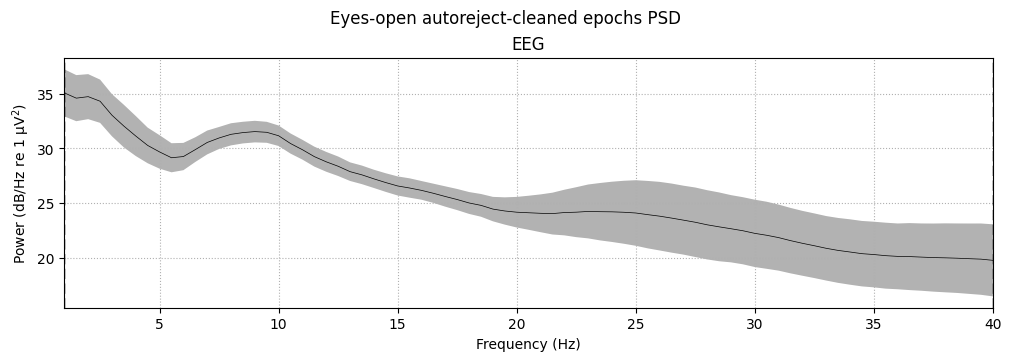

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


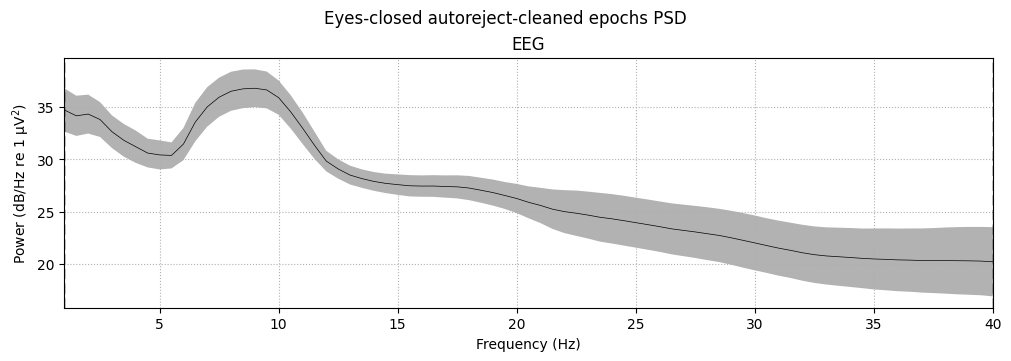

In [42]:
# Quick PSD check on autoreject-cleaned epochs
fig_open_ar = epochs_open_ar.compute_psd(fmin=1, fmax=40).plot(average=True, show=False)
fig_open_ar.suptitle("Eyes-open autoreject-cleaned epochs PSD")
plt.show()

fig_closed_ar = epochs_closed_ar.compute_psd(fmin=1, fmax=40).plot(average=True, show=False)
fig_closed_ar.suptitle("Eyes-closed autoreject-cleaned epochs PSD")
plt.show()
